## System Analyzer

In [ ]:
import sys
sys.path.append('..')

from include import *
from analyzer_functions import *

# Loading the config file
with open("system.conf", "r") as f:
    cfg = yaml.safe_load(f)

# Paths
sys_path = get_path(sub_path=cfg["paths"]["system"])
out_path = get_path(sub_path=cfg["paths"]["output"], main_path=sys_path)
rep_path = get_path(sub_path=cfg["paths"]["replicate"], main_path=out_path)
calm_path = get_path(sub_path=cfg["paths"]["calm"], main_path=rep_path)

# Files (Full paths to the files)
xtc = os.path.join(rep_path, cfg["files"]["xtc"])
pdb = os.path.join(rep_path, cfg["files"]["pdb"])
tpr = os.path.join(rep_path, cfg["files"]["tpr"])
dim = os.path.join(calm_path, cfg["files"]["dim"])
leaflets = os.path.join(out_path, cfg["files"]["leaflets"])
densmapBG = os.path.join(rep_path, cfg["files"]["densmapBG"])
densmapCDL0 = os.path.join(rep_path, cfg["files"]["densmapCDL0"])
densmapPOPC = os.path.join(rep_path, cfg["files"]["densmapPOPC"])

# beads
selections = cfg["beads"]

In [2]:
# Specifying the loaded information

# Loading the CALM analysis
trj_idxs, boxsizes = load_CALM_dimensions(dim)
# Load the system using MDAnalysis
system = load_mda_universe(pdb, xtc)
# Splitting the system up into a lower and upper membrane using the leaflet.ndx file
leaflets_ndx = load_leaflets_idx(leaflets)

/home/danie/miniconda3/envs/Thesis_WSL/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


Loading Leaflets from: /home/danie/erda/1wave_9010/output/leaflets.ndx


## Obtaining the positions from a MDA selection

In [3]:
def select_groups(system, leaflets_ndx, selections):
    """Splits the system up into groups. Groups are the information on specific atoms, 
    and we can use logica operators on them to easier select positions later.
    ARGS:
        system: the MDAnalysis universe object containing the loaded system
        leaflets_ndx: the indexes of the upper and lower leaflet, as loaded from the leaflets.ndx file
        selections: a dictionary containing the selection strings for the different groups we want to track (Should be available in the system)"""
    
    # Adding the selection to a group dictionary
    keys = selections.keys()
    groups = {
        key: system.select_atoms(selections[key]) for key in keys
    }
    # Adding the upper and lower leaflet information    
    groups["Upper"] = system.atoms[leaflets_ndx["Upper"]]
    groups["Lower"] = system.atoms[leaflets_ndx["Lower"]]

    return groups

# generate the positions of all atoms for the specific frame
def get_positions(system, groups, selections, trj_idxs):
    """Generates the positions of all atoms for the specific frame, from a given selection.
    These are then grouped together in a dictionary"""
    keys = selections.keys()
    # Splitting up the groups into upper and lower leaflets
    groups_to_track = {         # A generator object for storing the selections of the two leaflets.
        f"{key}_{leaflet}": groups[key] & groups[leaflet]
        for key in keys
        for leaflet in ["Upper", "Lower"]
    }
    
    # Pre-allocating the data dictionary to store the positions of all groups for the selected trajectory indices.
    n_trjs = len(trj_idxs)
    data_raw = {name: np.zeros((n_trjs, len(groups_to_track[name]), 3), dtype=float) for name in groups_to_track}
    
    # Preallocate for averaged PO4 positions
    data_raw["CDL_Upper"] = np.zeros((n_trjs, len(groups_to_track["PO4_1_Upper"]), 3))
    data_raw["CDL_Lower"] = np.zeros((n_trjs, len(groups_to_track["PO4_1_Lower"]), 3))
    
    # Generate the positions for all groups
    for i, frame in enumerate(tqdm(trj_idxs)):
        system.trajectory[frame]   # Move to the specific frame in the trajectory
        
        for name, g in groups_to_track.items():
            data_raw[name][i] = g.positions
            
        # For each frame we calculate the mean between the two PO4 groups, since this is the best representation of the headgroup position
        pos_CDL_upper = np.mean([data_raw["PO4_1_Upper"][i], data_raw["PO4_2_Upper"][i]], axis=0)
        pos_CDL_lower = np.mean([data_raw["PO4_1_Lower"][i], data_raw["PO4_2_Lower"][i]], axis=0)
        data_raw["CDL_Upper"][i] = pos_CDL_upper
        data_raw["CDL_Lower"][i] = pos_CDL_lower
        
        
    # Output some information on the generated data
    print("Number of trjs analyzed:", n_trjs)
    print("Available groups and their number of atoms:")
    for name, group in data_raw.items():
        print(f"    {name}: {len(group[0])} atoms")
    return data_raw, groups_to_track         # Data is structured as: data[group_name][frame_idx][atom_idx][x/y/z] (Has been crosschecked in vmd)

groups = select_groups(system, leaflets_ndx, selections)
positions, groups_to_track = get_positions(system, groups, selections, trj_idxs)

# Saving the atom positions for later use
np.savez(f"{cfg['paths']['system']}_{cfg['paths']['replicate']}_positions.npz", **positions)

100%|██████████| 251/251 [00:00<00:00, 440.95it/s]


Number of trjs analyzed: 251
Available groups and their number of atoms:
    PO4_1_Upper: 53 atoms
    PO4_1_Lower: 53 atoms
    PO4_2_Upper: 53 atoms
    PO4_2_Lower: 53 atoms
    NC3_Upper: 479 atoms
    NC3_Lower: 479 atoms
    CDL_Upper: 53 atoms
    CDL_Lower: 53 atoms


## Mapping positions to curvature for each leaflet

In [4]:
# Load the information on the frames we analyze
n_frames = len(trj_idxs)
mean_curv_fnames = get_CALM_frame_names(calm_path, filter="mean")
# Specify the keys for the curvature arrays
groups = ["NC3", "CDL"]
leaflets = ["Upper", "Lower"]

# Initialize curvature arrays
curvatures = {
    f"{g}_{l}": np.zeros(np.prod(np.shape(positions[f"{g}_{l}"])[:-1]))
    for g in groups
    for l in leaflets
}

for i in tqdm(range(n_frames)):
    # Load curvature maps
    curv_path = os.path.join(calm_path, mean_curv_fnames[i])
    curv_data = load_npy(mean_curv_fnames[i])
    curv_map = {
        leaflets[0]: curv_data[0],
        leaflets[1]: curv_data[1],
    }

    for g in groups:
        for l in leaflets:
            pos = positions[f"{g}_{l}"][i]
            curv = pos_to_curvature(curv_map[l], pos, boxsizes[i])

            # Where are we allocating the values in the array
            n = len(pos)
            start = i * n
            end = (i + 1) * n

            curvatures[f"{g}_{l}"][start:end] = curv

# Information on the curvature arrays
for key in curvatures:
    print(f"{key}: {len(curvatures[key])} curvature values")
    
# Saving the atom positions for later use
np.savez(f"{cfg['paths']['system']}_{cfg['paths']['replicate']}_curvature.npz", **curvatures)

100%|██████████| 251/251 [00:01<00:00, 142.97it/s]

NC3_Upper: 120229 curvature values
NC3_Lower: 120229 curvature values
CDL_Upper: 13303 curvature values
CDL_Lower: 13303 curvature values


## Plotting the curvature distribution

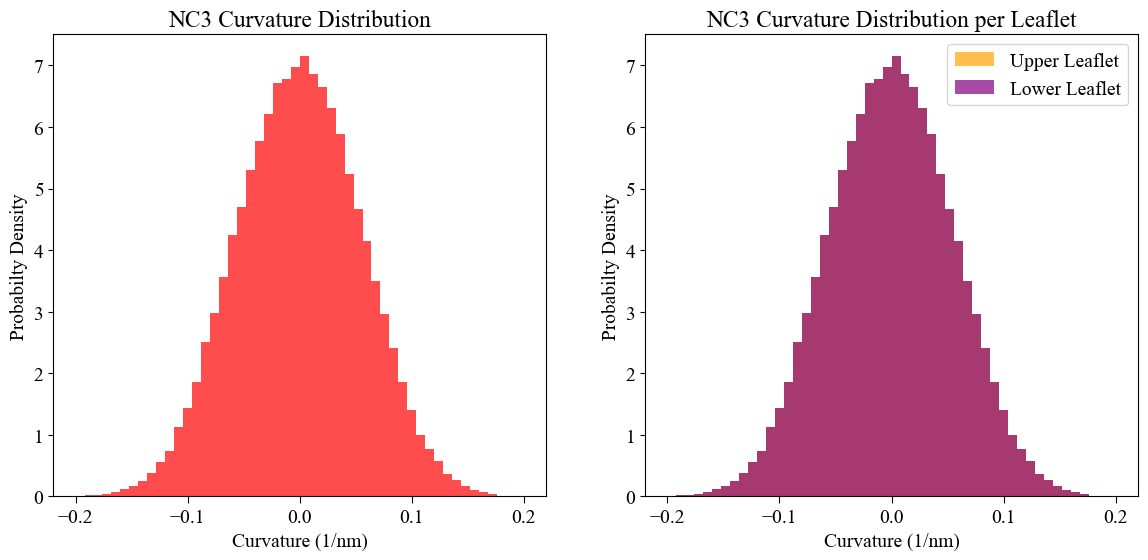

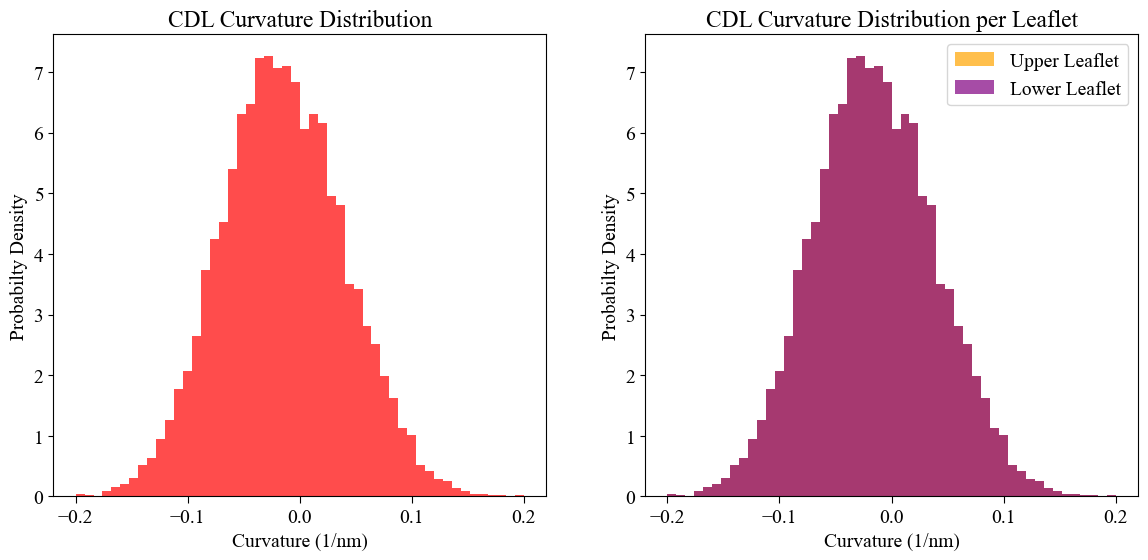

In [5]:
n_bins = 50
bin_range = (-0.2, 0.2)
groups = ["NC3", "CDL"]
leaflets = ["Upper", "Lower"]

for g in groups:
    for l in leaflets:
        upper = f"{g}_{l}"
        lower = f"{g}_{l}"
        
# Plotting the Curvature distribution fo the different species
    fig, ax = plt.subplots(1, 2, figsize=(14,6))
    curv_combined = np.concatenate([curvatures[upper], curvatures[lower]])

    ax[0].hist(curv_combined, bins=n_bins, range=bin_range, density=True, label="Both Leaflets", alpha=0.7, color="red");
    ax[1].hist(curvatures[upper], bins=n_bins, range=bin_range, density=True, label="Upper Leaflet", alpha=0.7, color="orange");
    ax[1].hist(curvatures[lower], bins=n_bins, range=bin_range, density=True, label="Lower Leaflet", alpha=0.7, color="purple");

    # Layout
    ax[0].set_title(f"{g} Curvature Distribution")
    ax[0].set_xlabel("Curvature (1/nm)")
    ax[0].set_ylabel("Probabilty Density")

    ax[1].set_title(f"{g} Curvature Distribution per Leaflet")
    ax[1].legend();
    ax[1].set_xlabel("Curvature (1/nm)")
    ax[1].set_ylabel("Probabilty Density")


## Removing structural bias

In [6]:
curvatures.keys()

### We combine all lipids in one background histogram
combined = np.concatenate([curvatures["NC3_Upper"], curvatures["NC3_Lower"], curvatures["CDL_Upper"], curvatures["CDL_Lower"]])
CDL_all = np.concatenate([curvatures["CDL_Upper"], curvatures["CDL_Lower"]])
POPC_combined = np.concatenate([curvatures["NC3_Upper"], curvatures["NC3_Lower"]])

n_bins = 40
bins = np.linspace(combined.min(), combined.max(), n_bins+1)

hist_all, _ = np.histogram(combined, bins=bins)
hist_CDL, _ = np.histogram(CDL_all, bins=bins)
hist_POPC, _ = np.histogram(POPC_combined, bins=bins)

# avoid division by zero
mask = hist_all > 0

P_CDL = np.zeros_like(hist_all, dtype=float)
P_CDL[mask] = hist_CDL[mask] / hist_all[mask]
# Bulk normalization to get the enrichment factor
bulk_CDL = len(CDL_all) / len(combined)

E_CDL = P_CDL / bulk_CDL

P_POPC = np.zeros_like(hist_all, dtype=float)
P_POPC[mask] = hist_POPC[mask] / hist_all[mask]
# Bulk normalization to get the enrichment factor
bulk_POPC = len(POPC_combined) / len(combined)
E_POPC = P_POPC / bulk_POPC

# compute bin centers
bin_centers = 0.5 * (bins[:-1] + bins[1:])

In [7]:
from stat_functions import *

# Calculating error propagation on two dependent variables (CDL and ALL) if CDL goes down this means that the total
# also goes down, so they are clearly dependent and the covariance should be accounted for
def Multivar_err_prop(deriv_vals, uncertainties):
    """Computes the error propagation for a multivariate function, given the derivative values and the uncertainties of the variables.
    ARGS:
        deriv_vals: a 2D array containing the derivative values for each variable and each data point (shape: n_variables x n_data_points)
        uncertainties: a 2D array containing the uncertainties for each variable and each data point (shape: n_variables x n_data_points)
        """
    # Compute the error propagation using the formula: sigma_f = sqrt( sum( (df/dx_i * sigma_x_i)^2 ) )
    squared_terms = (deriv_vals * uncertainties) ** 2    
    # Covariance term
    covariance_term = 2 * deriv_vals[0] * deriv_vals[1] * uncertainties[0] * uncertainties[1]
    # Summing the contributions together
    total_variance = np.sum(squared_terms, axis=0) + covariance_term      # Sums up the contributions from all variables for each data point

    return np.sqrt(total_variance)

# Creating the derivative values (We assume that if we use seperate POPC and CDL then they are maybe independent enough)
N_CDL, N_POPC = sp.symbols('x y')  # x = hist_CDL, y = hist_POPC
values = [hist_CDL, hist_POPC]   # Container for the values of the variables
uncertainties = np.array([np.sqrt(hist_CDL), np.sqrt(hist_POPC)])  # Uncertainties for each variable and each data point

# Calculating the error propagation values for the P_CDL and P_POPC
expr_CDL = N_CDL/(N_CDL+N_POPC)
deriv_expressions, deriv_vals_CDL, _ = get_derivatives(expr_CDL, [N_CDL, N_POPC], values=values)

expr_POPC = N_POPC/(N_CDL+N_POPC)
deriv_expressions, deriv_vals_POPC, _ = get_derivatives(expr_POPC, [N_CDL, N_POPC], values=values)

print("Derivatives (Expressions):", deriv_expressions)
print(f"Is value shape matching the number of data points? {np.array_equal(np.shape(deriv_vals_CDL), (2, n_bins))} - {np.shape(deriv_vals_CDL)}")

# Creating the error values with the formula for error propagation
P_CDL_err = Multivar_err_prop(deriv_vals_CDL, uncertainties=uncertainties)  # The uncertainties for each variable and each data point
P_POPC_err = Multivar_err_prop(deriv_vals_POPC, uncertainties=uncertainties)

# The error on the enrichment is simply the same error but scaled as there is no error on the bulk value
E_CDL_err = P_CDL_err / bulk_CDL
E_POPC_err = P_POPC_err / bulk_POPC


Derivatives (Expressions): [-y/(x + y)**2 -y/(x + y)**2 + 1/(x + y)]
Is value shape matching the number of data points? True - (2, 40)


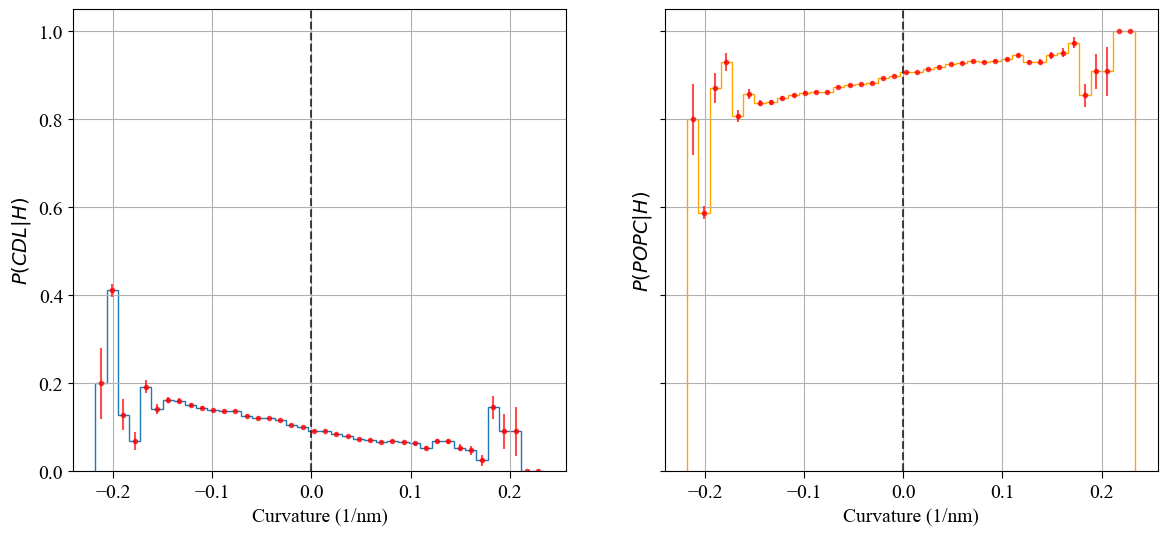

In [8]:
### Raw Plots ###
# Cardiolipin and POPC Curvature Preference (Probability of finding a lipid at a given curvature)
fig, ax = plt.subplots(1, 2, figsize=(14,6), sharex=True, sharey=True)
ax[0].stairs(P_CDL, bins, label="Cardiolipin")
ax[0].errorbar(bin_centers, P_CDL, yerr=P_CDL_err, fmt='.', color='red', alpha=0.7, label="Error")
ax[0].axvline(0, color='black', linestyle='--', alpha=0.7)

ax[1].stairs(P_POPC, bins, label="POPC", color="orange")
ax[1].errorbar(bin_centers, P_POPC, yerr=P_POPC_err, fmt='.', color='red', alpha=0.7, label="Error")
ax[1].axvline(0, color='black', linestyle='--', alpha=0.7)

# Layout
ax[0].set_xlabel("Curvature (1/nm)")
ax[0].set_ylabel("$P(CDL | H)$")
ax[1].set_xlabel("Curvature (1/nm)")
ax[1].set_ylabel("$P(POPC | H)$")
ax[0].grid()
ax[1].grid()

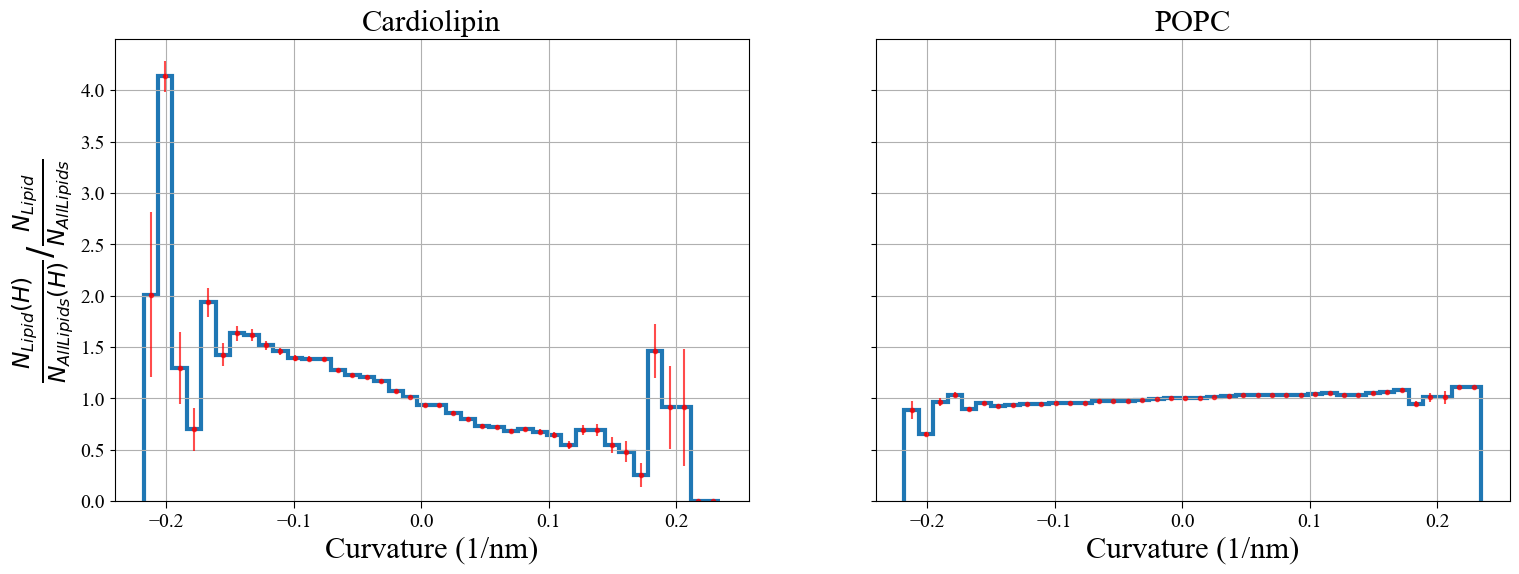

In [9]:
# Enrichment factor of CDL and POPC
fig, ax = plt.subplots(1, 2, figsize=(18,6), sharex=True, sharey=True)

# Plotting
ax[0].stairs(E_CDL, bins, label="Cardiolipin", lw=3)
ax[0].errorbar(bin_centers, E_CDL, yerr=E_CDL_err, fmt='.', color='r', alpha=0.7, label="Error")
ax[1].stairs(E_POPC, bins, label="POPC", lw=3)
ax[1].errorbar(bin_centers, E_POPC, yerr=E_POPC_err, fmt='.', color='r', alpha=0.7, label="Error")

# Layout
ax[0].set_xlabel("Curvature (1/nm)", fontsize=22)
ax[0].set_ylabel(r"$\frac{N_{Lipid}(H)}{N_{All Lipids}(H)} / \frac{N_{Lipid}}{N_{All Lipids}}$", fontsize=24)
ax[0].set_title("Cardiolipin", fontsize=22)
ax[1].set_xlabel("Curvature (1/nm)", fontsize=22)
ax[1].set_title("POPC", fontsize=22)
ax[0].grid()
ax[1].grid()